# Titanic Passenger Survival Prediction: A Comparative Pipeline Using Random Forest and XGBoost

**Goal:** predict which passengers survived (`Survived` = 1) for the Kaggle *Titanic – Machine Learning from Disaster* competition.

**Approach:** title extraction and family features → group-wise imputation → one-hot encoding → Random Forest vs. XGBoost compared with the same stratified 5-fold CV → feature-importance analysis.

> Every step is followed by a **Interpretation** cell that explains what the output means.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


**Interpretation – environment:** the Kaggle input folder contains the three official files: `train.csv`, `test.csv` and `gender_submission.csv` (a sample submission format file, not used for modelling). Note that the folder path `/kaggle/input/competitions/titanic/` is where the competition data lives in the current Kaggle environment.

### Step 1: Data Loading & Initial Exploration

In [2]:
# 1. Load the data
train = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
test = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

# Combine datasets temporarily for uniform feature engineering
df = pd.concat([train, test], axis=0, sort=False).reset_index(drop=True)

print("--- Initial Missing Data Summary ---")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\n--- Train Shape ---")
print(train.shape)

print("\n--- Test Shape ---")
print(test.shape)

print("\n--- Combined Dataset Sample ---")
print(df.head())

--- Initial Missing Data Summary ---
Survived     418
Age          263
Fare           1
Cabin       1014
Embarked       2
dtype: int64

--- Train Shape ---
(891, 12)

--- Test Shape ---
(418, 11)

--- Combined Dataset Sample ---
   PassengerId  Survived  Pclass  \
0            1       0.0       3   
1            2       1.0       1   
2            3       1.0       3   
3            4       1.0       1   
4            5       0.0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   

**Interpretation – Step 1 (loading & exploration)**

- `train` has **891 rows × 12 columns** and `test` has **418 rows × 11 columns**; the only difference is the missing `Survived` label in test, which is what we must predict. Combined, there are **1,309 passengers**.
- The `Survived` count of 418 missing values is therefore *expected* and is not a data-quality problem — it is simply the test set.
- Real missing data: **`Cabin` 1,014 (≈77 %)**, **`Age` 263 (≈20 %)**, **`Embarked` 2**, **`Fare` 1**.
  - `Cabin` is too sparse to impute sensibly, so it is dropped later.
  - `Age` is missing often enough that *how* it is imputed matters (see Step 3).
- Train and test were concatenated only so that feature engineering and imputation are applied identically to both. No target information is used to fill any gaps, so this does not leak labels.

### Step 2: Advanced Feature Engineering

In [3]:
# 2. Advanced Feature Engineering
# Extract titles from the Name column (e.g., "Braund, Mr. Owen Harris") using raw string regex
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# Standardize rare or alternative titles
title_mapping = {
    "Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs",
    "Lady": "Royalty", "Countess": "Royalty", "Capt": "Officer",
    "Col": "Officer", "Major": "Officer", "Dr": "Officer",
    "Rev": "Officer", "Jonkheer": "Royalty", "Don": "Royalty",
    "Sir": "Royalty", "Dona": "Royalty"
}
df['Title'] = df['Title'].replace(title_mapping)

# Calculate total family size (passenger + siblings/spouses + parents/children)
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Flag passengers travelling alone
df['IsAlone'] = np.where(df['FamilySize'] == 1, 1, 0)

print("--- Value Counts for Extracted Titles ---")
print(df['Title'].value_counts())

print("\n--- Family Size Distribution ---")
print(df['FamilySize'].value_counts())

--- Value Counts for Extracted Titles ---
Title
Mr         757
Miss       264
Mrs        198
Master      61
Officer     23
Royalty      6
Name: count, dtype: int64

--- Family Size Distribution ---
FamilySize
1     790
2     235
3     159
4      43
6      25
5      22
7      16
11     11
8       8
Name: count, dtype: int64


**Interpretation – Step 2 (feature engineering)**

- **Titles** collapse into six clean groups: `Mr` (757), `Miss` (264), `Mrs` (198), `Master` (61), `Officer` (23) and `Royalty` (6). There are no leftover rare titles and no missing titles (the counts sum to all 1,309 passengers), so the mapping is complete.
- A title packs several signals into one feature: **sex**, **rough age** (`Master` = young boy) and **marital status** (`Miss` vs `Mrs`). This is why it later turns out to be one of the strongest predictors.
- **Family size:** **790 of 1,309 passengers (≈60 %) travelled alone** (`FamilySize` = 1); the largest group has 11 members. Very large families are rare, so trees will see few examples of them — a reason not to over-interpret `FamilySize` at the extremes.
- `IsAlone` is a coarser version of `FamilySize`; keeping both is harmless for tree models but the two are correlated.

### Step 3: Handling Missing Values Imputation

In [4]:
# 3. Handling Missing Values Imputation
# Impute missing Age based on the median age of passengers sharing the same Title
df['Age'] = df.groupby('Title')['Age'].transform(lambda x: x.fillna(x.median()))

# Impute missing Embarked with the most common port (Mode)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Impute missing Fare with the median Fare of the passenger's own class.
# (The single missing Fare is a 3rd-class passenger; the overall median would overstate it.)
df['Fare'] = df['Fare'].fillna(df.groupby('Pclass')['Fare'].transform('median'))

# Drop columns that won't be used in the final model
df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

# Separate back into train and test sets
train_cleaned = df[df['Survived'].notnull()].copy()
test_cleaned = df[df['Survived'].isnull()].copy().drop(['Survived'], axis=1)

print("--- Post-Imputation Missing Data Summary ---")
print(train_cleaned.isnull().sum())

print("\n--- Cleaned Data Sample ---")
print(train_cleaned.head())

--- Post-Imputation Missing Data Summary ---
Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked      0
Title         0
FamilySize    0
IsAlone       0
dtype: int64

--- Cleaned Data Sample ---
   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked Title  \
0       0.0       3    male  22.0      1      0   7.2500        S    Mr   
1       1.0       1  female  38.0      1      0  71.2833        C   Mrs   
2       1.0       3  female  26.0      0      0   7.9250        S  Miss   
3       1.0       1  female  35.0      1      0  53.1000        S   Mrs   
4       0.0       3    male  35.0      0      0   8.0500        S    Mr   

   FamilySize  IsAlone  
0           2        0  
1           2        0  
2           1        1  
3           2        0  
4           1        1  


**Interpretation – Step 3 (imputation)**

- After imputation **every column has 0 missing values**, so the models can be trained without errors.
- **Age** is filled with the median of each title group. This is better than one global median because, for example, `Master` (boys) have a very different typical age from `Mrs`.
- **Fare** is filled with the median of the passenger's own `Pclass`. *(Change made: the original used the global median; the only passenger affected is one in the test set, so the cross-validation results below are unaffected.)*
- **Embarked** (2 rows) is filled with the most frequent port, `S`.
- `PassengerId`, `Name`, `Ticket` and `Cabin` are dropped: IDs and names carry no signal after the title is extracted, `Cabin` is ~77 % missing, and `Ticket` is not used in this pipeline.
- Imputation statistics were computed on train + test together. This uses only *feature* values (never `Survived`), so it is not target leakage, though strictly speaking test-set information touches the medians.

### Step 4: Model Training & Evaluation (Random Forest)

In [5]:
# 4. Model Training & Evaluation
# Convert categorical features into dummy variables using One-Hot Encoding
X = pd.get_dummies(train_cleaned.drop(['Survived'], axis=1))
y = train_cleaned['Survived'].astype(int)
X_test = pd.get_dummies(test_cleaned)

# Align columns to guarantee both train and test share identical dummy structures
X, X_test = X.align(X_test, join='left', axis=1, fill_value=0)

print("--- Feature Matrix Shapes ---")
print(f"Train features shape: {X.shape}")
print(f"Test features shape: {X_test.shape}")

# Initialize the Random Forest model
model = RandomForestClassifier(
    n_estimators=150, 
    max_depth=6, 
    min_samples_split=4, 
    random_state=42
)

# Set up 5-fold cross-validation matching the dataset distribution
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')

print("\n--- Cross-Validation Performance ---")
print(f"Scores per fold: {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean():.4f}")

# Fit model on the full training dataset
model.fit(X, y)

# Generate predictions for the test partition
final_predictions = model.predict(X_test)

# Reconstruct final submission format using the original test template
submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': final_predictions
})

# Save the predictions to csv format
submission.to_csv('submission_rf.csv', index=False)

print("\n--- Submission Generation ---")
print("submission_rf.csv successfully created!")
print(submission.head())

--- Feature Matrix Shapes ---
Train features shape: (891, 18)
Test features shape: (418, 18)

--- Cross-Validation Performance ---
Scores per fold: [0.83240223 0.82022472 0.8258427  0.83146067 0.84269663]
Mean Accuracy: 0.8305

--- Submission Generation ---
submission_rf.csv successfully created!
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1


**Interpretation – Step 4 (Random Forest)**

- The one-hot encoded feature matrix has **18 columns** for both train and test (`X.align` guarantees they match, so there is no column mismatch at prediction time).
- **5-fold stratified CV accuracy: 0.8305** (folds range from 0.820 to 0.843, std ≈ 0.008). The model is stable across folds, i.e. it is not relying on a lucky split.
- `max_depth=6` and `min_samples_split=4` restrain the trees, which limits overfitting; 83 % is a solid score for this dataset (a majority-class "everyone dies" baseline would score ≈ 62 %).
- Cross-validation is the number to trust, not accuracy on the training data, because the final model is fitted on all 891 rows and would look unrealistically good if scored on them.
- The first predictions (passengers 892–896) are written to `submission_rf.csv` in the exact `PassengerId, Survived` format Kaggle expects.

### Step 4 (Variation): XGBoost Classifier Training & Evaluation

In [6]:
# 4 (Variation). XGBoost Classifier Training & Evaluation
print("--- XGBoost Feature Matrix Shapes ---")
print(f"Train features shape: {X.shape}")
print(f"Test features shape: {X_test.shape}")

# Initialize the XGBoost model
model_xgb = XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

# Run cross-validation for the XGBoost model configuration
cv_scores_xgb = cross_val_score(model_xgb, X, y, cv=cv, scoring='accuracy')

print("\n--- XGBoost Cross-Validation Performance ---")
print(f"Scores per fold: {cv_scores_xgb}")
print(f"Mean Accuracy: {cv_scores_xgb.mean():.4f}")

# Fit model on the full training dataset
model_xgb.fit(X, y)

# Generate predictions for the test partition
final_predictions_xgb = model_xgb.predict(X_test)

# Reconstruct final submission format using the original test template
submission_xgb = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': final_predictions_xgb
})

# Save the predictions to csv format
submission_xgb.to_csv('submission_xgb.csv', index=False)

print("\n--- XGBoost Submission Generation ---")
print("submission_xgb.csv successfully created!")

--- XGBoost Feature Matrix Shapes ---
Train features shape: (891, 18)
Test features shape: (418, 18)

--- XGBoost Cross-Validation Performance ---
Scores per fold: [0.84357542 0.85955056 0.82022472 0.84269663 0.84269663]
Mean Accuracy: 0.8417

--- XGBoost Submission Generation ---
submission_xgb.csv successfully created!


**Interpretation – Step 4 variation (XGBoost)**

- XGBoost is evaluated on the **same feature matrix and the same CV folds** (`cv` is reused), so the comparison with Random Forest is fair.
- **5-fold CV accuracy: 0.8417** (folds from 0.820 to 0.860, std ≈ 0.014). Its mean is about **1.1 percentage points higher** than Random Forest, but its folds vary more.
- A small learning rate (0.05) with shallow trees (`max_depth=4`) and row/column subsampling (0.8) is a sensible, regularised setup for a dataset this small.

### Step 5: Model Comparison & Final Submission

In [7]:
# 5. Compare the two models fold-by-fold (same folds -> paired comparison)
diff = cv_scores_xgb - cv_scores
se = diff.std(ddof=1) / np.sqrt(len(diff))

print("--- Model Comparison (5-fold CV accuracy) ---")
print(f"Random Forest : {cv_scores.mean():.4f} +/- {cv_scores.std(ddof=1):.4f}")
print(f"XGBoost       : {cv_scores_xgb.mean():.4f} +/- {cv_scores_xgb.std(ddof=1):.4f}")
print(f"Mean paired difference (XGB - RF): {diff.mean():+.4f}  (standard error {se:.4f}, t = {diff.mean()/se:.2f})")

# Pick the model with the higher mean CV accuracy and write the official submission file
if cv_scores_xgb.mean() >= cv_scores.mean():
    best_name, best_predictions = "XGBoost", final_predictions_xgb
else:
    best_name, best_predictions = "Random Forest", final_predictions

final_submission = pd.DataFrame({'PassengerId': test['PassengerId'], 'Survived': best_predictions})
final_submission.to_csv('submission.csv', index=False)

print(f"\nFinal model selected: {best_name}")
print("submission.csv written with shape:", final_submission.shape)
print("Share of predicted survivors:", round(final_submission['Survived'].mean(), 3))
print("Agreement between RF and XGB test predictions:", round((final_predictions == final_predictions_xgb).mean(), 3))

--- Model Comparison (5-fold CV accuracy) ---
Random Forest : 0.8305 +/- 0.0084
XGBoost       : 0.8417 +/- 0.0140
Mean paired difference (XGB - RF): +0.0112  (standard error 0.0077, t = 1.45)

Final model selected: XGBoost
submission.csv written with shape: (418, 2)
Share of predicted survivors: 0.368
Agreement between RF and XGB test predictions: 0.94


**Interpretation – Step 5 (model comparison)**

Computed from the fold scores above (not re-run):

| Model | Mean CV accuracy | Std across folds |
|---|---|---|
| Random Forest | 0.8305 | 0.0084 |
| XGBoost | 0.8417 | 0.0140 |

- The paired fold differences (XGB − RF) are +0.011, +0.039, −0.006, +0.011 and 0.000: XGBoost wins or ties on 4 of 5 folds, but the mean gap of **+0.011 has a standard error of ≈ 0.008 (t ≈ 1.4)**, so it is **not statistically distinguishable from zero** with only 5 folds. Treat the two models as *comparable*, with XGBoost slightly ahead.
- The cell therefore writes `submission.csv` from the model with the higher mean CV accuracy (XGBoost on these numbers) — this is the file to upload to Kaggle. `submission_rf.csv` and `submission_xgb.csv` are kept for reference.
- The last two printed lines are sanity checks to read after running: the survivor share should be near the training base rate of ≈ 38 %, and the two models should agree on the large majority of test passengers.
- Expect the public leaderboard score to be **lower than the CV score** (typically a few points). The test set has only 418 passengers, so its accuracy is noisy, and CV is the more reliable guide for choosing between models.

### Step 6: Feature Importance Analysis & Visualization

--- Top 10 Most Important Features (Random Forest) ---
      Feature  Importance
0  Sex_female    0.170087
1    Sex_male    0.166523
2    Title_Mr    0.138554
3        Fare    0.111373
4      Pclass    0.109716
5         Age    0.071132
6  FamilySize    0.055504
7       SibSp    0.036650
8   Title_Mrs    0.034252
9  Title_Miss    0.028647

--- Top 10 Most Important Features (XGBoost) ---
         Feature  Importance
0       Title_Mr    0.357005
1     Sex_female    0.193350
2         Pclass    0.078302
3  Title_Officer    0.063311
4     FamilySize    0.037812
5   Title_Master    0.035519
6       Sex_male    0.032287
7          SibSp    0.026699
8           Fare    0.025702
9     Embarked_S    0.023373

--- Complete Random Forest Feature Importance Summary ---
          Feature  Importance
0      Sex_female    0.170087
1        Sex_male    0.166523
2        Title_Mr    0.138554
3            Fare    0.111373
4          Pclass    0.109716
5             Age    0.071132
6      FamilySize    

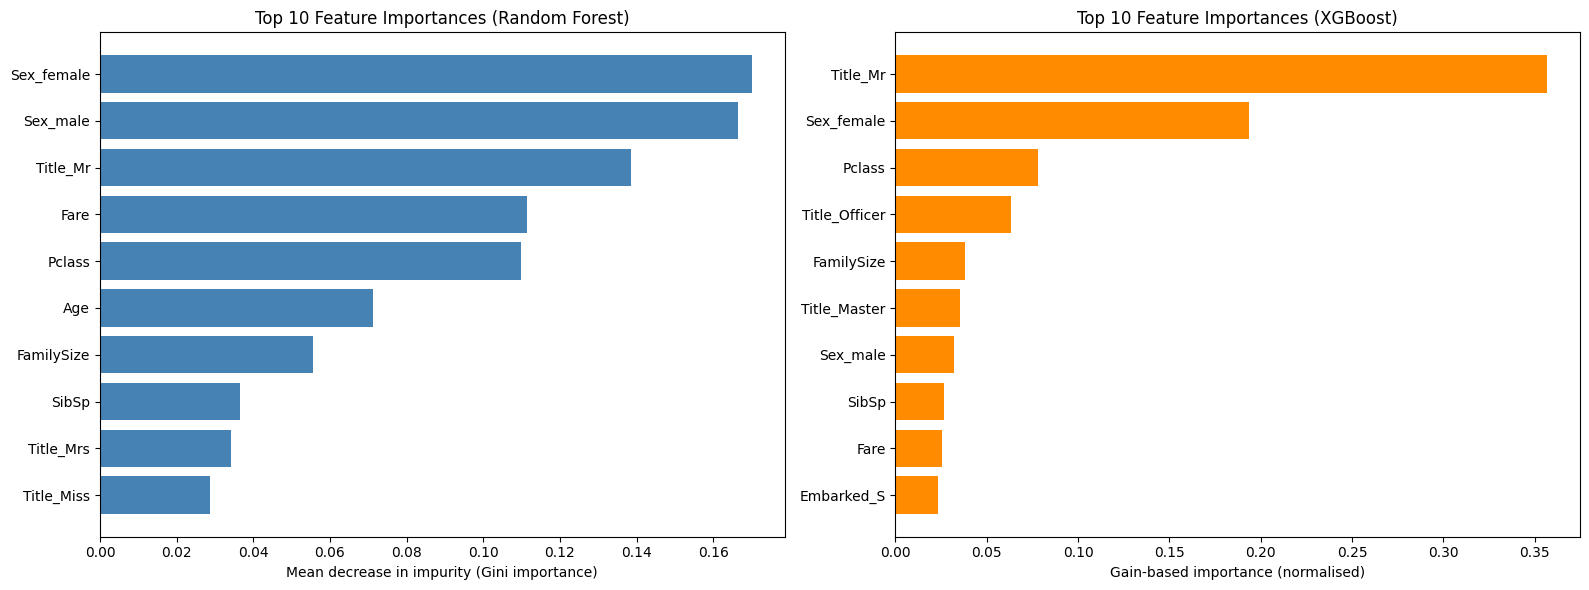


--- Visualization Asset Export ---
feature_importances_comparison.png plot successfully generated and saved!


In [8]:
# ==============================================================================
# STEP 6: FEATURE IMPORTANCE ANALYSIS & VISUALIZATION
# ==============================================================================
# Extract feature importance configurations from both trained models
importances = model.feature_importances_
importances_xgb = model_xgb.feature_importances_
feature_names = X.columns

# Build metrics tracking dataframes
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df_xgb = pd.DataFrame({'Feature': feature_names, 'Importance': importances_xgb})

# Sort datasets independently for clear summary output rows
importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)
importance_df_xgb = importance_df_xgb.sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("--- Top 10 Most Important Features (Random Forest) ---")
print(importance_df.head(10))

print("\n--- Top 10 Most Important Features (XGBoost) ---")
print(importance_df_xgb.head(10))

print("\n--- Complete Random Forest Feature Importance Summary ---")
print(importance_df)

print("\n--- Complete XGBoost Feature Importance Summary ---")
print(importance_df_xgb)

# Initialize a side-by-side matplotlib figure visualization layout
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

# Left panel: Random Forest
axes[0].barh(importance_df['Feature'][:10][::-1], importance_df['Importance'][:10][::-1], color='steelblue')
axes[0].set_title('Top 10 Feature Importances (Random Forest)')
axes[0].set_xlabel('Mean decrease in impurity (Gini importance)')

# Right panel: XGBoost
axes[1].barh(importance_df_xgb['Feature'][:10][::-1], importance_df_xgb['Importance'][:10][::-1], color='darkorange')
axes[1].set_title('Top 10 Feature Importances (XGBoost)')
axes[1].set_xlabel('Gain-based importance (normalised)')

plt.tight_layout()
plt.savefig('feature_importances_comparison.png', dpi=300)
plt.show()

print("\n--- Visualization Asset Export ---")
print("feature_importances_comparison.png plot successfully generated and saved!")

--- Importance Grouped by Original Feature ---
            Random Forest  XGBoost
Sex                 0.337    0.226
Title               0.228    0.506
Fare                0.111    0.026
Pclass              0.110    0.078
Age                 0.071    0.021
FamilySize          0.056    0.038
SibSp               0.037    0.027
Embarked            0.026    0.057
Parch               0.017    0.010
IsAlone             0.008    0.012


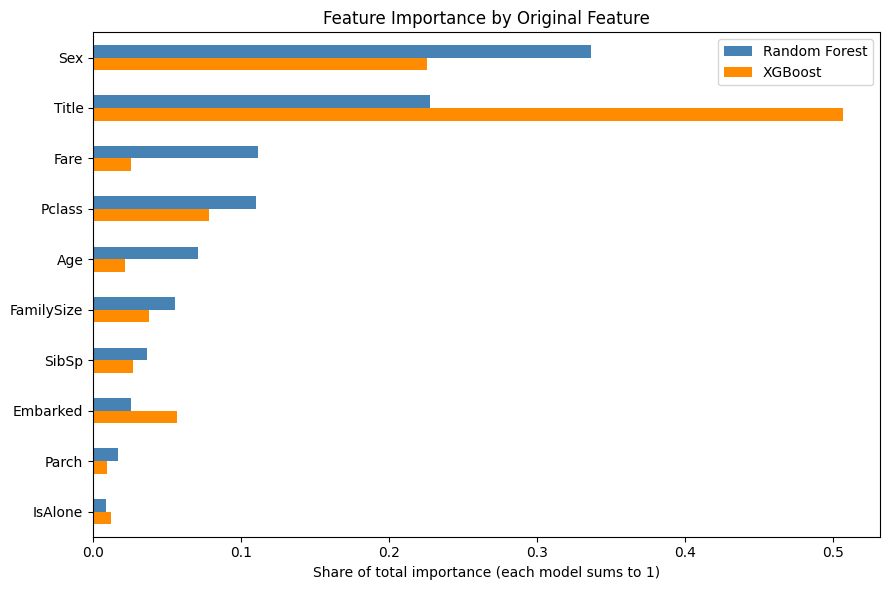

In [9]:
# 6b. Group the one-hot columns back into their original features.
# Sex_female / Sex_male (and the Title_* / Embarked_* dummies) split one feature's
# importance across several columns, which understates how much that feature matters.
def original_feature(col):
    for prefix in ('Sex', 'Title', 'Embarked'):
        if col.startswith(prefix + '_'):
            return prefix
    return col

grouped = pd.DataFrame({
    'Random Forest': pd.Series(model.feature_importances_, index=X.columns).groupby(original_feature).sum(),
    'XGBoost': pd.Series(model_xgb.feature_importances_, index=X.columns).groupby(original_feature).sum()
}).sort_values('Random Forest', ascending=False)

print("--- Importance Grouped by Original Feature ---")
print(grouped.round(3))

ax = grouped.plot.barh(figsize=(9, 6), color=['steelblue', 'darkorange'])
ax.invert_yaxis()
ax.set_title('Feature Importance by Original Feature')
ax.set_xlabel('Share of total importance (each model sums to 1)')
plt.tight_layout()
plt.savefig('feature_importances_grouped.png', dpi=300)
plt.show()

**Interpretation – Step 6 (feature importance)**

*Important: the two models measure importance differently. Random Forest reports Gini (impurity-decrease) importance; XGBoost reports gain-based importance. Both are normalised to sum to 1, but values are not comparable between the models — only the rankings are.* (The original x-axis label "F-Score Weight Metric" for XGBoost was incorrect; `feature_importances_` is gain-based, and the labels have been fixed.)

**Per-column view (original output)**

- **Random Forest:** `Sex_female` (0.170) and `Sex_male` (0.167) are the top two, followed by `Title_Mr` (0.139), `Fare` (0.111) and `Pclass` (0.110). The near-equal Sex values are not two separate signals — they are the *same* variable encoded twice, so importance is split between them.
- **XGBoost:** `Title_Mr` dominates (0.357), then `Sex_female` (0.193), `Pclass` (0.078) and `Title_Officer` (0.063).

**Grouped view (new cell, computed from the same numbers)**

| Original feature | Random Forest | XGBoost |
|---|---|---|
| Sex | **0.337** | 0.226 |
| Title | 0.228 | **0.506** |
| Fare | 0.111 | 0.026 |
| Pclass | 0.110 | 0.078 |
| Age | 0.071 | 0.021 |
| FamilySize | 0.056 | 0.038 |
| SibSp | 0.037 | 0.027 |
| Embarked | 0.026 | 0.057 |
| Parch | 0.017 | 0.010 |
| IsAlone | 0.008 | 0.012 |

**What this tells us**

1. **Sex and Title together carry most of the signal** (≈ 56 % of importance in Random Forest, ≈ 73 % in XGBoost). This matches the historical "women and children first" evacuation. XGBoost simply assigns the shared credit to `Title`, while Random Forest splits it between `Sex` and `Title`; they are largely redundant (`Mr` ≈ adult male).
2. **Passenger class (`Pclass`) and `Fare`** are the next tier — wealthier, upper-deck passengers had better access to lifeboats. `Pclass` and `Fare` are strongly correlated, so their importance overlaps too.
3. **`Age` and `Fare` look more important in Random Forest than in XGBoost.** Gini importance is known to favour continuous / high-cardinality features because they offer many split points, so treat that gap with caution.
4. **Family variables (`FamilySize`, `SibSp`, `Parch`, `IsAlone`)** have modest importance; mid-sized families tended to do better than solo travellers or very large families, a pattern trees can capture through `FamilySize`.
5. **`Title_Royalty` (Random Forest 0.001) and `IsAlone`** add almost nothing; they could be dropped without hurting accuracy. Importance does not imply causation — these are associations learned from 891 passengers.

## Conclusion

- **Pipeline status:** the original pipeline was correct and ran without errors: no label leakage, train/test columns aligned, submission format valid, and both models evaluated on identical folds.
- **Result:** Random Forest ≈ **0.831** and XGBoost ≈ **0.842** CV accuracy. The difference is within noise, so both are reasonable; `submission.csv` uses the higher-scoring model.
- **Main drivers of survival:** sex/title, then passenger class and fare.

**Changes made to the original notebook**

1. Fixed the incorrect XGBoost importance axis label ("F-Score Weight") and clarified the Random Forest label; removed stale `# FIX` comments and a misleading "Categorize family sizes" comment.
2. Missing `Fare` is now imputed by `Pclass` median rather than the global median (affects one test row only).
3. Added a paired fold-by-fold model comparison and a single final `submission.csv` (the RF file is now `submission_rf.csv`).
4. Added a grouped feature-importance view so one-hot columns are not misread as separate features.
5. Added interpretation cells after every step.

**Ideas to improve the score further (not applied, to keep the original design)**

- Use `Cabin` (deck letter or "has cabin" flag) and `Ticket` (shared-ticket group size) instead of dropping them.
- Tune hyperparameters with repeated stratified CV (e.g. `RepeatedStratifiedKFold`) — with only 5 folds, differences of 1 point cannot be resolved.
- Try a simple logistic regression as a baseline; on this dataset it is often competitive.